--2026-05-08 15:00:20--  https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30696129 (29M) [text/csv]
Saving to: ‘fake_news.csv’

fake_news.csv       100%[===================>]  29.27M  15.9MB/s    in 1.8s    

2026-05-08 15:00:23 (15.9 MB/s) - ‘fake_news.csv’ saved [30696129/30696129]



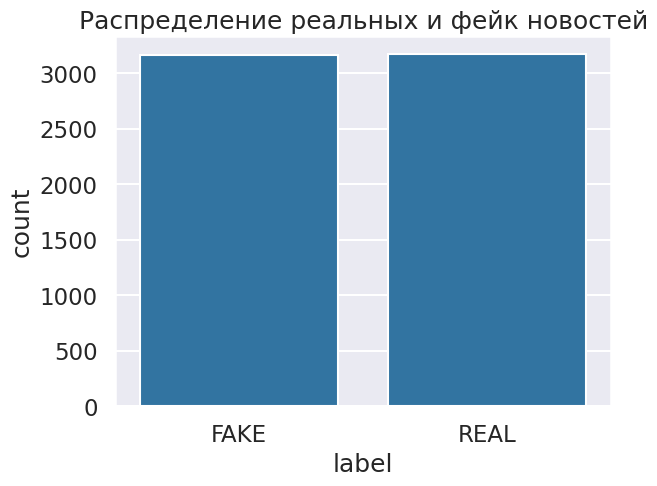

Accuracy Score: 94.71%
              precision    recall  f1-score   support

        FAKE       0.95      0.95      0.95       651
        REAL       0.94      0.95      0.95       616

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



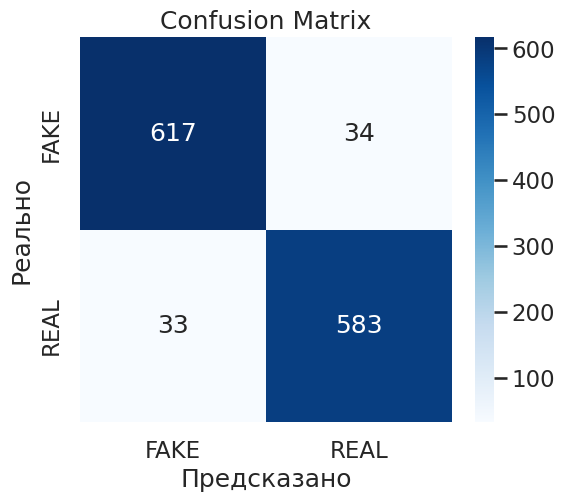

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

!wget "https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv"

data = pd.read_csv('fake_news.csv')
#plt = make_subplots(rows=4, cols=1)

sns.set_context('talk')
sns.set_style('darkgrid')

sns.countplot(data, x='label')
plt.title('Распределение реальных и фейк новостей')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=1)

tfidf = TfidfVectorizer(max_df=0.7, stop_words='english')
x_train_tfidf = tfidf.fit_transform(X_train)
x_test_tfidf = tfidf.transform(X_test)

pac = PassiveAggressiveClassifier(max_iter=1000, random_state=1)
pac.fit(x_train_tfidf, y_train)

y_pred = pac.predict(x_test_tfidf)

score = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {round(score*100,2)}%')
print(classification_report(y_test, y_pred))
# +
fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = score*100,
    title = {'text': "Model Accuracy (%)"},
    gauge = {'axis': {'range': [0, 100]}}
))

fig.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'])

plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Confusion Matrix")
plt.show()